In [173]:
!pip install ultralytics pillow

In [1]:

from ultralytics import YOLO

model = YOLO("yolo11n.pt")  # Use "yolov8n.pt" for smaller model, "yolov8x.pt" for larger


def detect_and_crop_objects(image_path):
    # Load a pretrained YOLOv8 model

    # Load your image
    image_ = Image.open(image_path)
    width, height = image_.size
    image = image_.resize((600, int(height * 600 / width)))
    # image = image_.resize((width // 2, height // 2))
    # Perform object detection
    results = model.predict(image)
    # Extract bounding boxes, labels, and confidence scores
    boxes = results[0].boxes.xyxy.tolist()  # Bounding box coordinates (x1, y1, x2, y2)
    confidences = results[0].boxes.conf.tolist()  # Confidence scores
    class_ids = results[0].boxes.cls.tolist()  # Class IDs

    # Create a directory to save cropped objects
    os.makedirs("cropped_objects", exist_ok=True)

    # Crop and save detected objects
    cropped_images = []
    for i, (box, conf, cls_id) in enumerate(zip(boxes, confidences, class_ids)):
        x1, y1, x2, y2 = map(int, box)

        # Check if the object is fully visible
        # if x1 > 0 and y1 > 0 and x2 <= width and y2 <= height:
        cropped_image = image.crop((x1, y1, x2, y2))
        cropped_image.save(f"cropped_objects/object_{i}.jpg")
        cropped_images.append(cropped_image)
        print(f"Cropped Object {i}: Class ID {cls_id}, Confidence {conf:.2f} {x1} {y1} {x2} {y2} ")

    print(f"Cropped {len(cropped_images)} fully visible objects!")

    # Display cropped images
    for i, cropped_image in enumerate(cropped_images):
        plt.figure()
        plt.imshow(cropped_image)
        plt.title(f"Cropped Object {i}")
        plt.axis('off')
        plt.show()


# Example usage
detect_and_crop_objects("img_test_6.webp")

FileNotFoundError: [Errno 2] No such file or directory: 'img_test_17.webp'


0: 640x480 1 person, 1 cup, 1 tv, 1 mouse, 1 keyboard, 57.2ms
Speed: 1.4ms preprocess, 57.2ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 480)
Cropped Object 0: Class ID 41.0, Confidence 0.92
Cropped Object 1: Class ID 0.0, Confidence 0.90
Cropped Object 2: Class ID 64.0, Confidence 0.77
Cropped Object 3: Class ID 66.0, Confidence 0.51
Cropped Object 4: Class ID 62.0, Confidence 0.46
Cropped 5 objects!


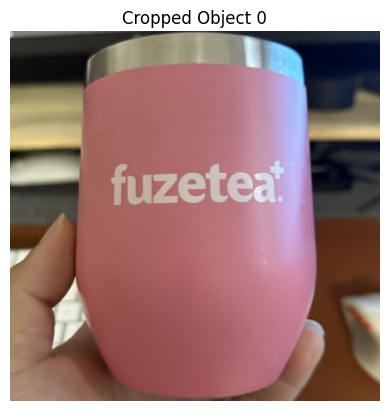

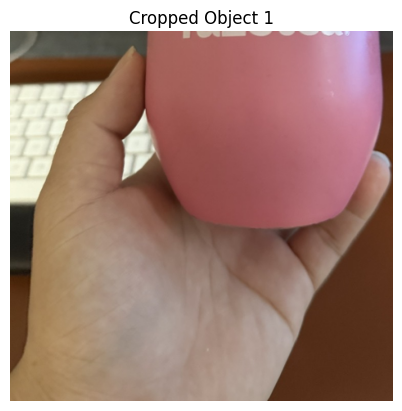

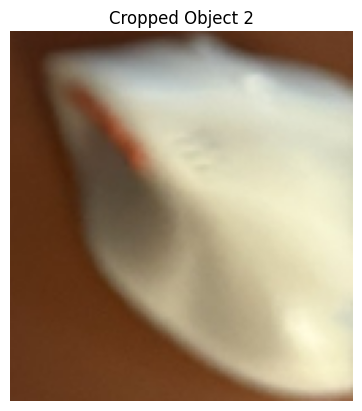

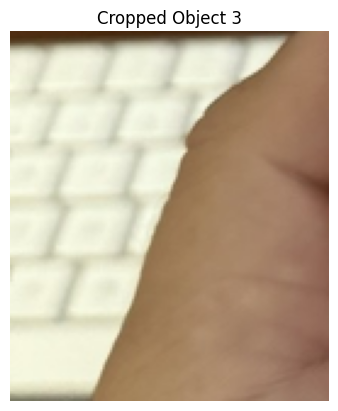

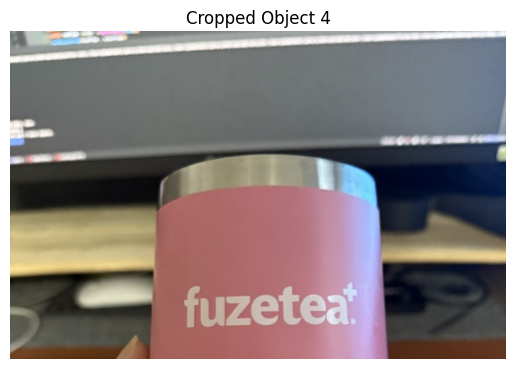

In [4]:

from ultralytics import YOLO

model = YOLO("yolo11n.pt")  # Use "yolov8n.pt" for smaller model, "yolov8x.pt" for larger


def detect_and_crop_objects(image_path):
    # Load your image
    image_ = Image.open(image_path)
    width, height = image_.size
    image = image_.resize((600, int(height * 600 / width)))

    # Perform object detection
    results = model.predict(image)

    # Extract bounding boxes, labels, and confidence scores
    boxes = results[0].boxes.xyxy.tolist()  # Bounding box coordinates (x1, y1, x2, y2)
    confidences = results[0].boxes.conf.tolist()  # Confidence scores
    class_ids = results[0].boxes.cls.tolist()  # Class IDs

    # Create a directory to save cropped objects
    os.makedirs("cropped_objects", exist_ok=True)

    # Crop and save detected objects
    cropped_images = []
    for i, (box, conf, cls_id) in enumerate(zip(boxes, confidences, class_ids)):
        x1, y1, x2, y2 = map(int, box)
        obj_width = x2 - x1
        obj_height = y2 - y1

        # Calculate the center of the object
        center_x = x1 + obj_width // 2
        center_y = y1 + obj_height // 2

        # Define the size of the cropped image
        crop_size = max(obj_width, obj_height)
        crop_x1 = max(0, center_x - crop_size // 2)
        crop_y1 = max(0, center_y - crop_size // 2)
        crop_x2 = min(image.width, center_x + crop_size // 2)
        crop_y2 = min(image.height, center_y + crop_size // 2)

        # Crop the image
        cropped_image = image.crop((crop_x1, crop_y1, crop_x2, crop_y2))
        cropped_image.save(f"cropped_objects/object_{i}.jpg")
        cropped_images.append(cropped_image)
        print(f"Cropped Object {i}: Class ID {cls_id}, Confidence {conf:.2f}")

    print(f"Cropped {len(cropped_images)} objects!")

    # Display cropped images
    for i, cropped_image in enumerate(cropped_images):
        plt.figure()
        plt.imshow(cropped_image)
        plt.title(f"Cropped Object {i}")
        plt.axis('off')
        plt.show()


# Example usage
# detect_and_crop_objects("img_test_6.webp")

detect_and_crop_objects("img_test_17.jpg")


0: 640x320 2 mouses, 1 keyboard, 1 cell phone, 66.6ms
Speed: 4.0ms preprocess, 66.6ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 320)
Cropped Object 0: Class ID 64.0, Confidence 0.93 285 165 581 298 
Cropped Object 1: Class ID 64.0, Confidence 0.79 29 647 574 1001 
Cropped Object 2: Class ID 66.0, Confidence 0.69 1 65 230 293 
Cropped Object 3: Class ID 67.0, Confidence 0.63 30 648 572 1001 
Cropped 4 fully visible objects!


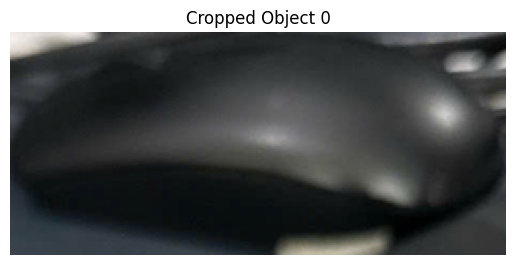

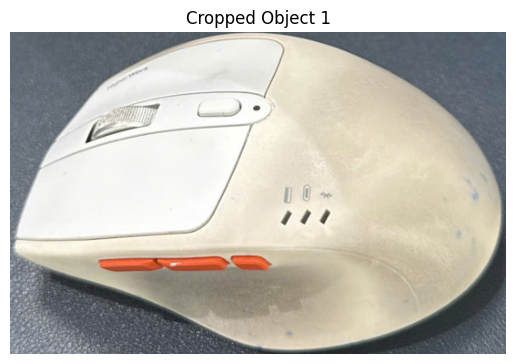

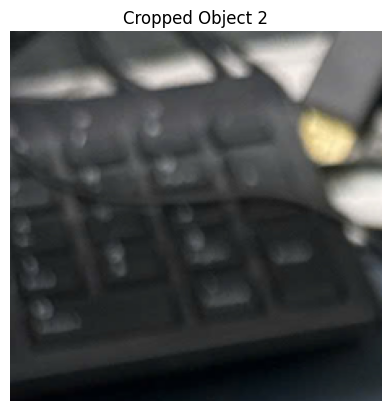

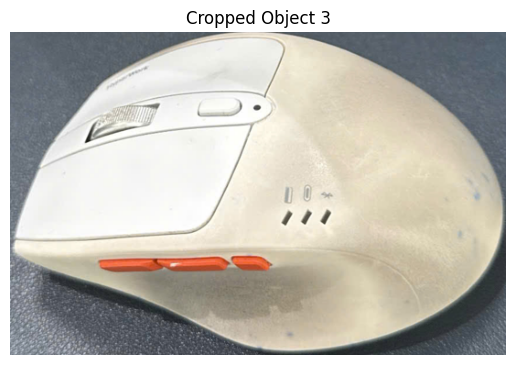

In [176]:
detect_and_crop_objects("img_test_3.jpg")


0: 640x640 1 book, 141.6ms
Speed: 4.2ms preprocess, 141.6ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)
Cropped Object 0: Class ID 73.0, Confidence 0.31 95 75 515 534 
Cropped 1 fully visible objects!


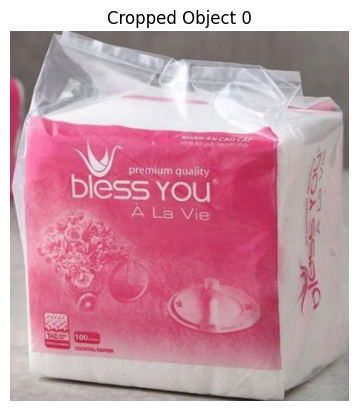

In [177]:
detect_and_crop_objects("img_test_6.webp")


0: 480x640 2 tvs, 3 mouses, 2 keyboards, 1 book, 91.9ms
Speed: 2.6ms preprocess, 91.9ms inference, 0.8ms postprocess per image at shape (1, 3, 480, 640)
Cropped Object 0: Class ID 64.0, Confidence 0.94 421 230 523 342 
Cropped Object 1: Class ID 66.0, Confidence 0.89 6 119 352 272 
Cropped Object 2: Class ID 62.0, Confidence 0.81 432 0 599 145 
Cropped Object 3: Class ID 64.0, Confidence 0.77 442 117 553 165 
Cropped Object 4: Class ID 66.0, Confidence 0.68 2 60 401 146 
Cropped Object 5: Class ID 62.0, Confidence 0.60 1 0 439 71 
Cropped Object 6: Class ID 64.0, Confidence 0.55 361 165 434 211 
Cropped Object 7: Class ID 73.0, Confidence 0.51 90 241 442 427 
Cropped 8 fully visible objects!


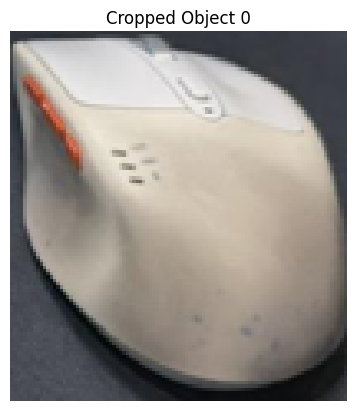

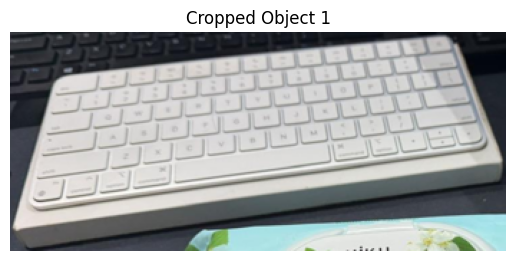

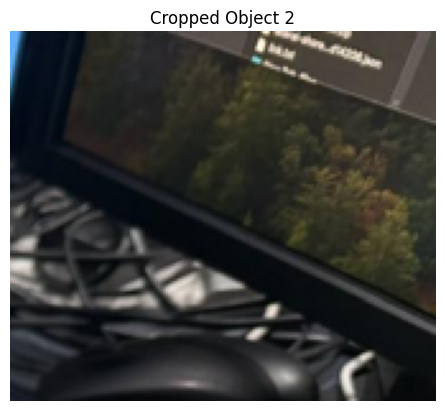

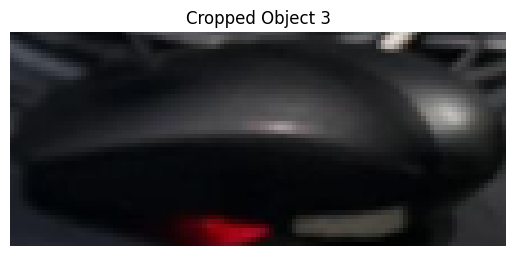

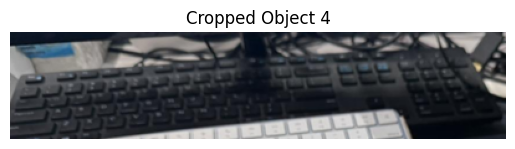

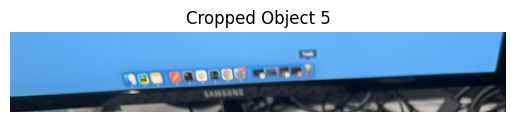

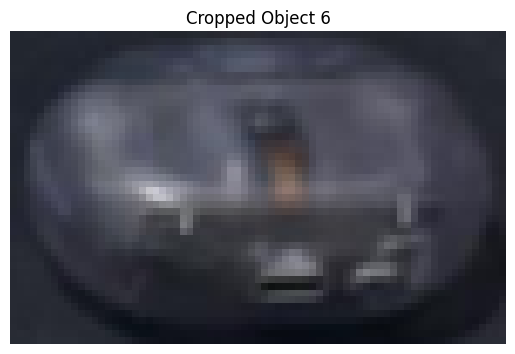

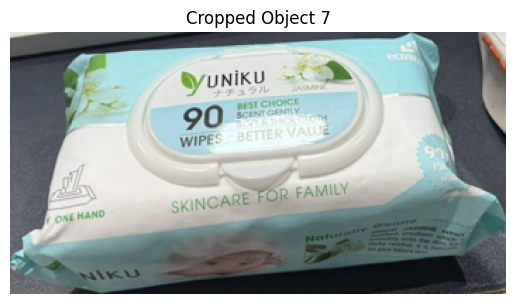

In [178]:
detect_and_crop_objects("img_test_16.jpg")


0: 640x480 1 person, 1 cup, 1 mouse, 1 keyboard, 75.2ms
Speed: 2.4ms preprocess, 75.2ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 480)
Cropped Object 0: Class ID 41.0, Confidence 0.92 132 117 490 623
Cropped Object 1: Class ID 0.0, Confidence 0.90 0 335 500 829
Cropped Object 2: Class ID 64.0, Confidence 0.77 456 429 629 625
Cropped Object 3: Class ID 66.0, Confidence 0.51 0 378 141 591
Cropped 4 objects!


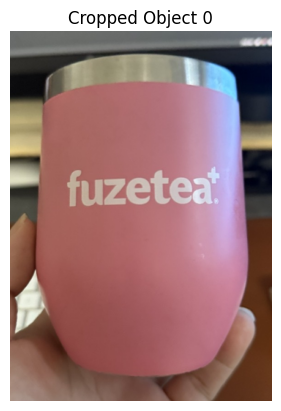

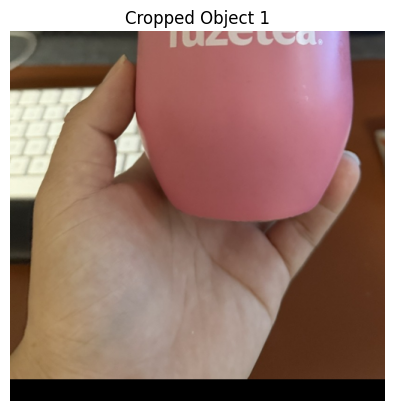

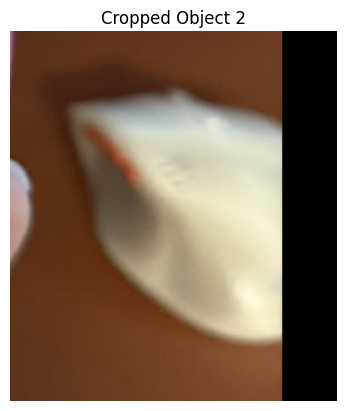

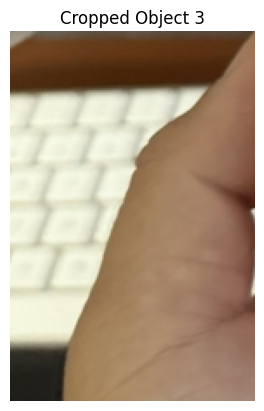

In [13]:
from ultralytics import YOLO
from PIL import Image
import os
import matplotlib.pyplot as plt

model = YOLO("yolo11n.pt")  # Use "yolov8n.pt" for smaller model, "yolov8x.pt" for larger


def detect_and_crop_objects(image_path):
    # Load your image
    image_ = Image.open(image_path)
    width, height = image_.size
    image = image_.resize((600, int(height * 600 / width)))

    # Perform object detection
    results = model.predict(image, conf=0.25)
    # Extract bounding boxes, labels, and confidence scores
    boxes = results[0].boxes.xyxy.tolist()  # Bounding box coordinates (x1, y1, x2, y2)
    confidences = results[0].boxes.conf.tolist()  # Confidence scores
    class_ids = results[0].boxes.cls.tolist()  # Class IDs

    # Create a directory to save cropped objects
    os.makedirs("cropped_objects", exist_ok=True)

    # Crop and save detected objects
    cropped_images = []
    padding = 30  # Padding in pixels

    for i, (box, conf, cls_id) in enumerate(zip(boxes, confidences, class_ids)):
        x1, y1, x2, y2 = map(int, box)

        # Expand the bounding box with padding
        x1 = max(x1 - padding, 0)
        y1 = max(y1 - padding, 0)
        x2 = min(x2 + padding, width)
        y2 = min(y2 + padding, height)

        # Crop the image
        cropped_image = image.crop((x1, y1, x2, y2))
        cropped_image.save(f"cropped_objects/object_{i}.jpg")
        cropped_images.append(cropped_image)
        print(f"Cropped Object {i}: Class ID {cls_id}, Confidence {conf:.2f} {x1} {y1} {x2} {y2}")

    print(f"Cropped {len(cropped_images)} objects!")

    # Display cropped images
    for i, cropped_image in enumerate(cropped_images):
        plt.figure()
        plt.imshow(cropped_image)
        plt.title(f"Cropped Object {i}")
        plt.axis('off')
        plt.show()


# Example usage
detect_and_crop_objects("img_test_17.jpg")